# DIGITAL TRANSACTION RISK ANALYSIS
## Unit VI: Time-Series Analysis and Forecasting

This final unit analyzes the temporal patterns of transaction data. We investigate trends, seasonality, and autocorrelation, apply smoothing techniques, and build an ARIMA model to forecast future transaction behavior.

In [1]:
!pip install statsmodels


Defaulting to user installation because normal site-packages is not writeable
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 4.1 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.6 MB 3.5 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.6 MB 3.6 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.6 MB 3.0 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.6 MB 2.8 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.6 MB 2.6 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.6 MB 2.6 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.6 MB 2.6 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.6 MB 2.6 MB/s eta 0:00:02
   --------------------- ---------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Matplotlib is building the font cache; this may take a moment.


Loading dataset...


Time series created from 2019-01-01 to 2020-06-21


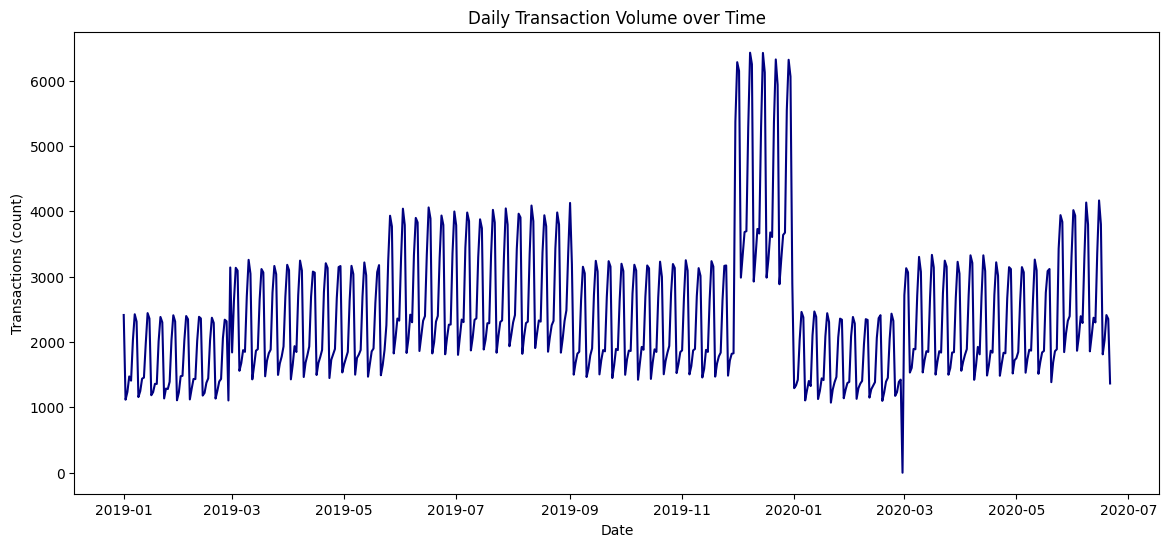

In [2]:
# ================================================================
# SETUP: DEPENDENCIES AND DATA AGGREGATION
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

print("Loading dataset...")
df = pd.read_csv('fraudTrain.csv')

# Convert to datetime and aggregate transaction VOLUME by day (count of transactions)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

ts_daily = (
    df.set_index('trans_date_trans_time')
      .sort_index()
      .resample('D')
      .size()
      .asfreq('D', fill_value=0)
)

print(f"Time series created from {ts_daily.index.min().date()} to {ts_daily.index.max().date()}")
plt.figure(figsize=(14, 6))
plt.plot(ts_daily, color='navy')
plt.title('Daily Transaction Volume over Time')
plt.xlabel('Date')
plt.ylabel('Transactions (count)')
plt.show()


## 1. Trend and Seasonality Decomposition
**Objective:** Break the time series into its constituent components: Trend, Seasonality, and Residuals.


TIME SERIES DECOMPOSITION


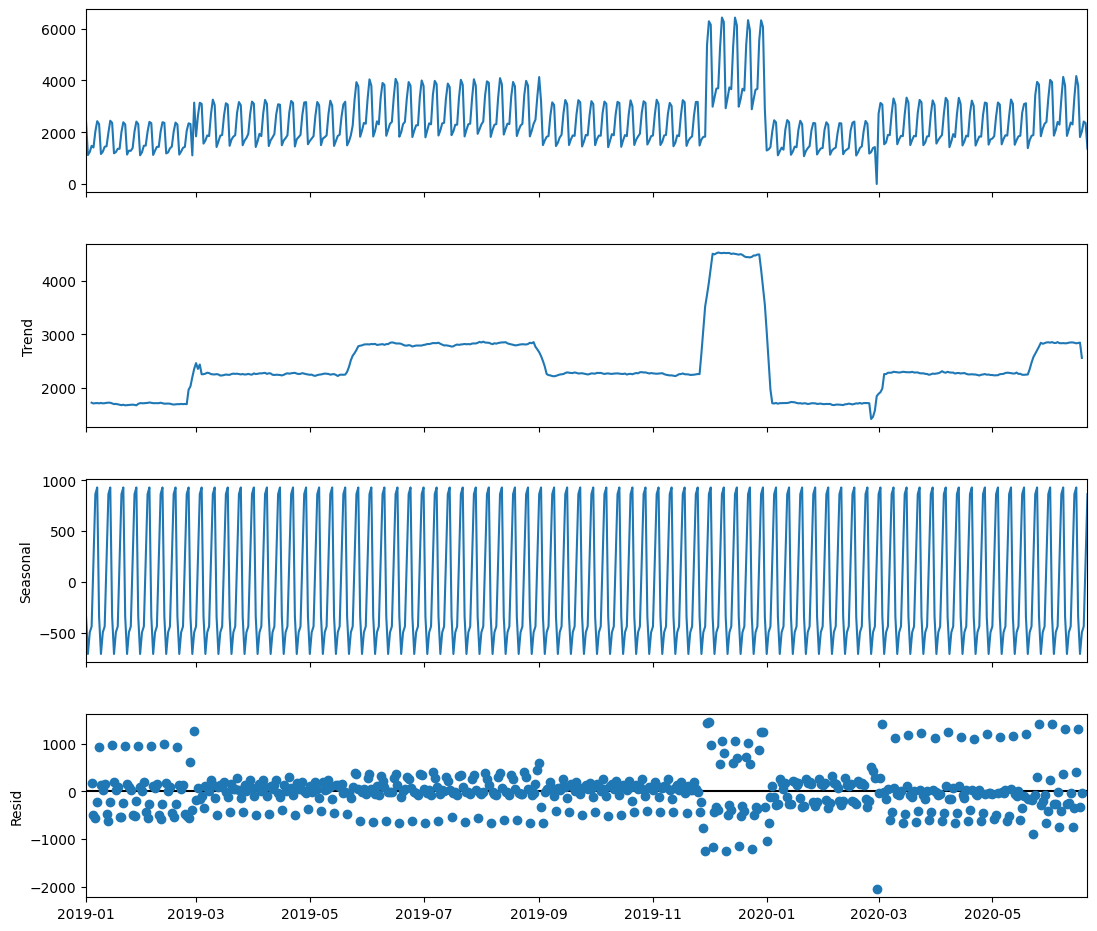

Interpretation: The plots show a clear weekly seasonality in transaction habits.


In [3]:
print('\n' + '='*60)
print('TIME SERIES DECOMPOSITION')
print('='*60)

decomposition = seasonal_decompose(ts_daily.dropna(), model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()

print("Interpretation: The plots show a clear weekly seasonality in transaction habits.")


## 2. Smoothing Techniques: Moving Average & Exponential Smoothing
**Objective:** Filter noise using Moving Average and predict the next value using Exponential Smoothing.


SMOOTHING TECHNIQUES


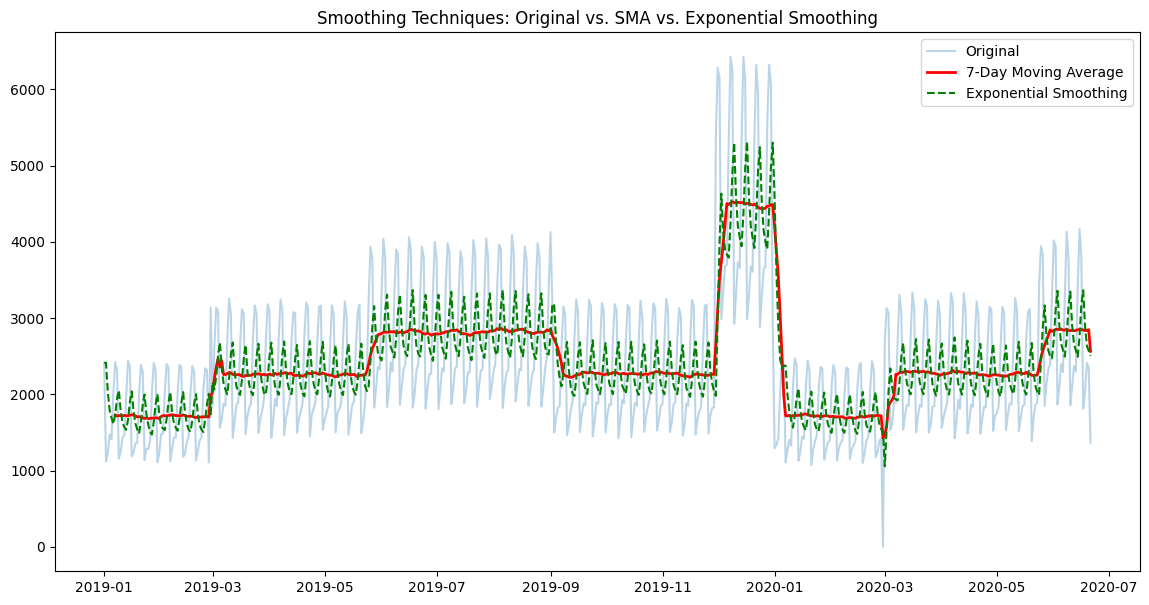

In [4]:
print('\n' + '='*60)
print('SMOOTHING TECHNIQUES')
print('='*60)

# Simple Moving Average (7-day window)
sma_7 = ts_daily.rolling(window=7).mean()

# Exponential Smoothing
model_es = SimpleExpSmoothing(ts_daily.dropna()).fit(smoothing_level=0.3, optimized=False)
es_forecast = model_es.fittedvalues

plt.figure(figsize=(14, 7))
plt.plot(ts_daily, label='Original', alpha=0.3)
plt.plot(sma_7, label='7-Day Moving Average', color='red', lw=2)
plt.plot(es_forecast, label='Exponential Smoothing', color='green', linestyle='--')
plt.title('Smoothing Techniques: Original vs. SMA vs. Exponential Smoothing')
plt.legend()
plt.show()


## 3. Autocorrelation (ACF) and PACF
**Objective:** Determine the correlation of the series with its own past values to identify AR and MA components.

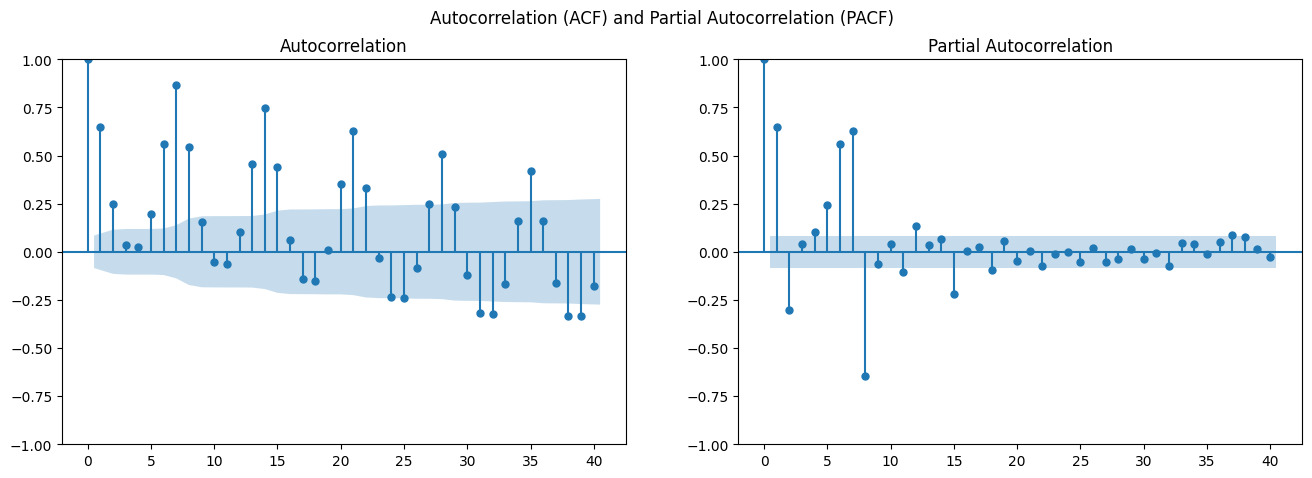

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts_daily.dropna(), lags=40, ax=ax1)
plot_pacf(ts_daily.dropna(), lags=40, ax=ax2)
plt.suptitle('Autocorrelation (ACF) and Partial Autocorrelation (PACF)')
plt.show()


## 4. ARIMA Modeling and Forecasting
**Objective:** Build a predictive model and forecast the transaction volume for the next 30 days.


ARIMA MODELING AND FORECASTING
ADF Statistic: -3.4895
p-value: 8.2602e-03
Series is stationary.


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  538
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4317.698
Date:                Tue, 05 May 2026   AIC                           8641.395
Time:                        09:11:24   BIC                           8654.253
Sample:                    01-01-2019   HQIC                          8646.425
                         - 06-21-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5451      0.041     13.414      0.000       0.465       0.625
ma.L1         -0.9406      0.016    -58.933      0.000      -0.972      -0.909
sigma2      5.633e+05   2.87e+04     19.617      0.0

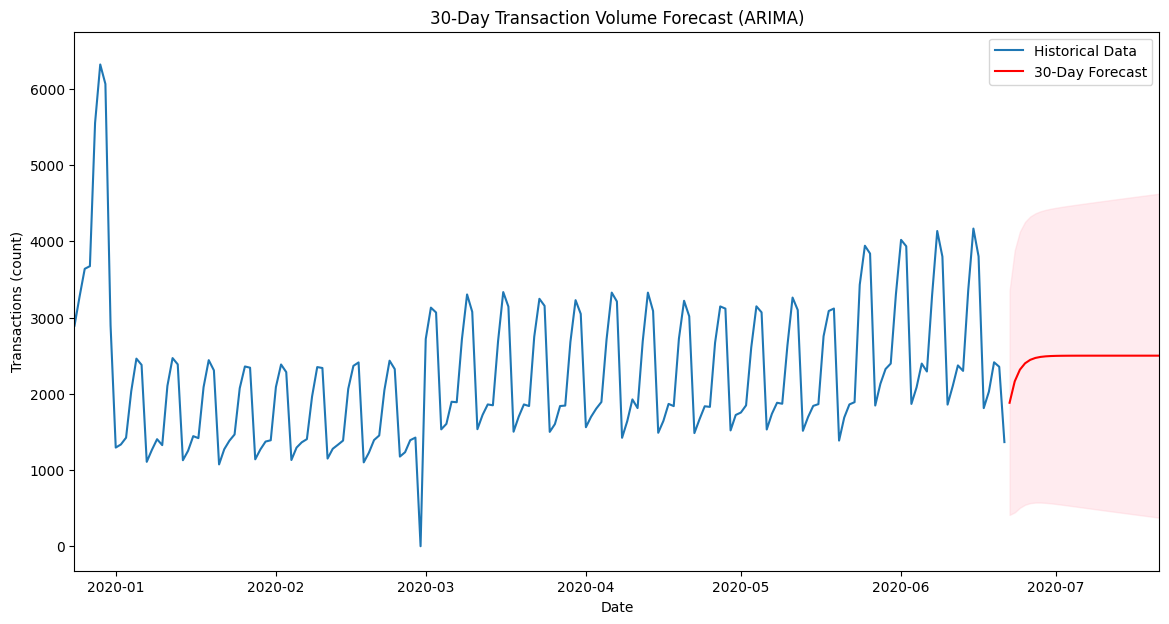

UNIT VI COMPLETE: PROJECT COMPLETED


In [6]:
print('\n' + '='*60)
print('ARIMA MODELING AND FORECASTING')
print('='*60)

series = ts_daily

# Step 4a: Stationarity Check (Augmented Dickey-Fuller Test)
result = adfuller(series)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4e}")
if result[1] < 0.05:
    print("Series is stationary.")
else:
    print("Series is not stationary. Differencing required.")

# Step 4b: Fit ARIMA Model (using p=1, d=1, q=1 as a baseline)
# Note: In a real project, you'd use auto_arima or a grid search to optimize these.
model_arima = ARIMA(series, order=(1, 1, 1))
results_arima = model_arima.fit()
print(results_arima.summary())

# Step 4c: Forecasting the next 30 days
forecast_steps = 30
forecast_res = results_arima.get_forecast(steps=forecast_steps)
forecast_ci = forecast_res.conf_int()

# Ensure forecast is indexed by future calendar days (prevents the plot from landing at 1970)
forecast_index = pd.date_range(
    start=series.index[-1] + pd.Timedelta(days=1),
    periods=forecast_steps,
    freq='D',
)

forecast_mean = pd.Series(forecast_res.predicted_mean.to_numpy(), index=forecast_index)
forecast_ci.index = forecast_index

plt.figure(figsize=(14, 7))
plt.plot(series, label='Historical Data')
plt.plot(forecast_mean, color='red', label='30-Day Forecast')
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0].to_numpy(),
    forecast_ci.iloc[:, 1].to_numpy(),
    color='pink',
    alpha=0.3,
)

# Focus the view so the forecast is readable
plt.xlim(series.index.max() - pd.Timedelta(days=180), forecast_index.max())

plt.title('30-Day Transaction Volume Forecast (ARIMA)')
plt.xlabel('Date')
plt.ylabel('Transactions (count)')
plt.legend()
plt.show()

print("=" * 60)
print("UNIT VI COMPLETE: PROJECT COMPLETED")
print("=" * 60)
